# Week 2 — Monte Carlo Simulation
## Project 04: Long-term Mine Planning — Simultaneous NPV and Throughput Optimization

### Objectives
- Load and explore the 500-block block model
- Simulate grade uncertainty using Monte Carlo (Normal distribution, CV=15%)
- Run 200 scenarios and compute expected NPV + std dev per block
- Plot NPV distribution and grade uncertainty fan chart

---

## 0. Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)          # reproducibility
print('Libraries loaded ✓')

Libraries loaded ✓


In [13]:
df = pd.read_csv('block_model.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]} blocks, {df.shape[1]} columns')
df.head()

Shape: (500, 15)  →  500 blocks, 15 columns


,block_id,x,y,z,tonnage_kt,ore_grade_pct,waste_ratio,mining_cost_t,processing_cost_t,revenue_per_t,slope_constraint,period_available,ghg_kg_co2_per_t,stripping_ratio,npv_per_t
0,B0000,800,750,-100,573.5,0.668,3.21,4.38,12.13,90.12,3,8,26.02,2.32,73.61
1,B0001,850,550,-50,534.9,0.751,1.65,2.95,11.27,82.96,1,4,31.26,1.04,68.74
2,B0002,850,250,-40,362.6,0.771,2.58,4.39,12.27,112.22,1,2,28.57,1.35,95.56
3,B0003,450,300,-90,420.9,0.763,0.70,3.37,14.59,123.39,2,8,25.26,2.42,105.43
4,B0004,150,550,-80,474.7,0.875,3.21,4.83,10.49,93.26,2,5,29.41,3.18,77.94


In [14]:
df.describe().round(2)

,x,y,z,tonnage_kt,ore_grade_pct,waste_ratio,mining_cost_t,processing_cost_t,revenue_per_t,slope_constraint,period_available,ghg_kg_co2_per_t,stripping_ratio,npv_per_t
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,487.00,470.80,-55.26,502.23,0.82,2.50,4.16,12.16,84.20,2.01,5.28,27.45,2.57,67.88
std,281.83,296.18,28.99,76.93,0.16,0.80,0.58,1.97,15.16,0.83,2.79,5.09,0.81,15.21
min,0.00,0.00,-100.00,311.30,0.24,0.50,2.50,8.00,41.08,1.00,1.00,15.00,0.50,25.68
25%,250.00,200.00,-80.00,446.98,0.71,1.95,3.76,10.65,72.96,1.00,3.00,23.76,1.98,57.37
50%,500.00,500.00,-60.00,501.30,0.82,2.49,4.20,12.14,83.93,2.00,5.00,27.60,2.62,67.42
75%,750.00,750.00,-30.00,556.25,0.94,3.04,4.50,13.52,94.55,3.00,8.00,30.77,3.13,78.33
max,950.00,950.00,-10.00,722.50,1.25,4.88,6.03,18.00,126.80,3.00,10.00,42.29,4.81,111.34


In [15]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
block_id             0
x                    0
y                    0
z                    0
tonnage_kt           0
ore_grade_pct        0
waste_ratio          0
mining_cost_t        0
processing_cost_t    0
revenue_per_t        0
slope_constraint     0
period_available     0
ghg_kg_co2_per_t     0
stripping_ratio      0
npv_per_t            0
dtype: int64


In [ ]:
# Parameters 
N_SCENARIOS = 200
CV          = 0.15     # coefficient of variation = σ/μ

n_blocks = len(df)

#Build grade matrix (n_blocks × N_SCENARIOS)
# Each row = one block; each column = one Monte Carlo scenario
mu_grade = df['ore_grade_pct'].values                  # shape (500,)
sigma_grade = CV * mu_grade                             # σ = CV × μ

# Draw all samples at once 
# Result shape: (500, 200)
grade_matrix = np.random.normal(
    loc   = mu_grade[:, np.newaxis],      # broadcast mean across columns
    scale = sigma_grade[:, np.newaxis],   # broadcast std  across columns
    size  = (n_blocks, N_SCENARIOS)
)

# Clip negative grades to zero (physically impossible)
grade_matrix = np.clip(grade_matrix, 0, None)

print(f'Grade matrix shape: {grade_matrix.shape}  (blocks × scenarios)')
print(f'Min simulated grade: {grade_matrix.min():.4f}%')
print(f'Max simulated grade: {grade_matrix.max():.4f}%')

Grade matrix shape: (500, 200)  (blocks × scenarios)
Min simulated grade: 0.1130%
Max simulated grade: 1.8217%


In [17]:
#Compute NPV matrix (n_blocks × N_SCENARIOS) 
revenue      = df['revenue_per_t'].values[:, np.newaxis]
mining_cost  = df['mining_cost_t'].values[:, np.newaxis]
proc_cost    = df['processing_cost_t'].values[:, np.newaxis]
tonnage      = df['tonnage_kt'].values[:, np.newaxis]
nom_grade    = mu_grade[:, np.newaxis]

# Scale revenue by simulated grade
simulated_revenue = revenue * grade_matrix / nom_grade

# npv_per_t   = revenue - mining_cost - processing_cost
# total_npv   = npv_per_t * tonnage_kt * 1000
npv_per_t_matrix = simulated_revenue - mining_cost - proc_cost
npv_matrix       = npv_per_t_matrix * tonnage * 1000   # kt → t

print(f'NPV matrix shape: {npv_matrix.shape}')
print(f'Total NPV range: [{npv_matrix.min():,.0f}, {npv_matrix.max():,.0f}] $')

NPV matrix shape: (500, 200)
Total NPV range: [3,252,035, 97,361,711] $



Expected NPV and Standard Deviation per Block

Averaging across all 200 scenarios gives us:
- **E[NPV]** — the expected (mean) economic value per block
- **σ[NPV]** — the uncertainty/risk around that value

In [18]:
df['npv_expected'] = npv_matrix.mean(axis=1)   # mean across 200 scenarios
df['npv_std']      = npv_matrix.std(axis=1)    # std  across 200 scenarios
df['npv_cv'] = np.where(df['npv_expected'].abs() > 1e-9,
                        df['npv_std'] / df['npv_expected'].abs(),
                        np.nan)  # relative uncertainty

print('Summary of simulated NPV per block')
print(df[['npv_expected','npv_std','npv_cv']].describe().round(3))

Summary of simulated NPV per block
       npv_expected       npv_std   npv_cv
count  5.000000e+02  5.000000e+02  500.000
mean   3.407255e+07  6.324312e+06    0.188
std    9.239392e+06  1.525975e+06    0.015
min    1.263242e+07  2.640008e+06    0.154
25%    2.717530e+07  5.191234e+06    0.177
50%    3.343670e+07  6.243011e+06    0.187
75%    4.011263e+07  7.362070e+06    0.196
max    6.206980e+07  1.089913e+07    0.259


In [19]:
# Top 5 highest expected NPV blocks
print('Top 5 blocks by Expected NPV:')
df[['block_id','ore_grade_pct','npv_expected','npv_std','period_available']]\
  .sort_values('npv_expected', ascending=False).head()

Top 5 blocks by Expected NPV:


,block_id,ore_grade_pct,npv_expected,npv_std,period_available
169,B0169,0.832,6.206980e+07,1.069908e+07,8
326,B0326,0.939,6.060791e+07,9.867700e+06,9
193,B0193,0.505,5.864984e+07,1.048759e+07,5
219,B0219,0.821,5.769764e+07,1.012263e+07,3
280,B0280,0.859,5.709275e+07,1.053934e+07,3


In [20]:
# Top 5 highest RISK (std dev) blocks
print('Top 5 blocks by NPV Uncertainty (std dev):')
df[['block_id','ore_grade_pct','npv_expected','npv_std']]\
  .sort_values('npv_std', ascending=False).head()

Top 5 blocks by NPV Uncertainty (std dev):


,block_id,ore_grade_pct,npv_expected,npv_std
264,B0264,0.805,5.028789e+07,1.089913e+07
169,B0169,0.832,6.206980e+07,1.069908e+07
280,B0280,0.859,5.709275e+07,1.053934e+07
193,B0193,0.505,5.864984e+07,1.048759e+07
14,B0014,0.735,5.428997e+07,1.048589e+07



Visualisation

Plot A — NPV Distribution (all blocks, all scenarios)

Plot B — Grade Uncertainty Fan Chart (10 selected blocks)

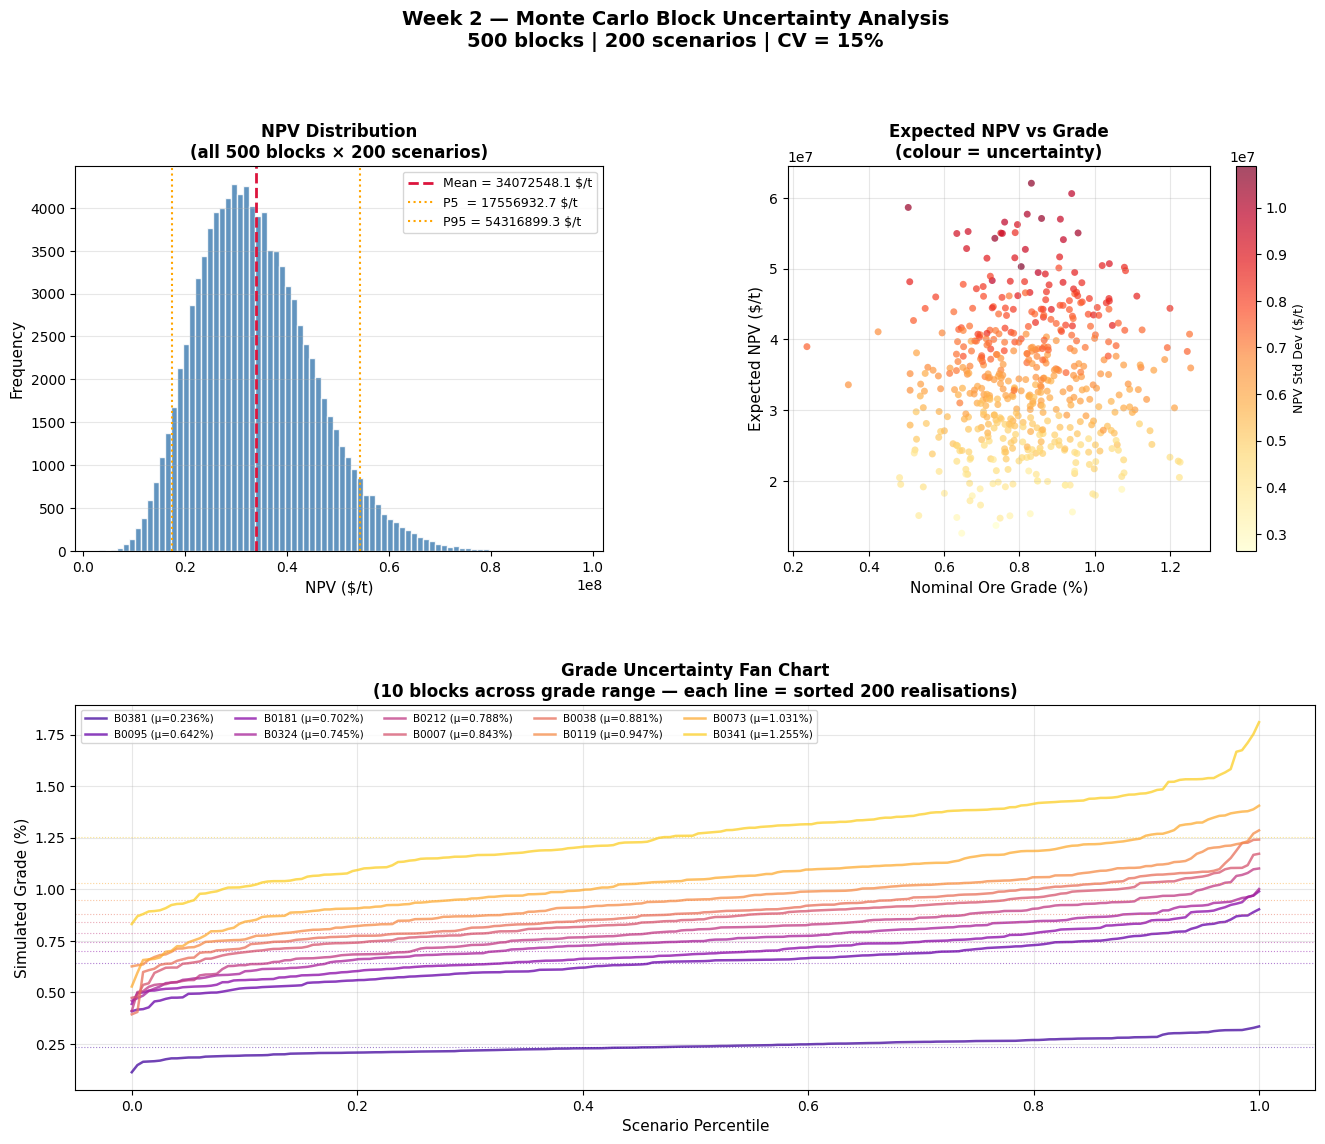

In [ ]:
fig = plt.figure(figsize=(16, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# Plot 1: Histogram of ALL simulated NPV values 
ax1 = fig.add_subplot(gs[0, 0])
all_npv = npv_matrix.flatten()
ax1.hist(all_npv, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(all_npv.mean(), color='crimson', linewidth=2, linestyle='--',
            label=f'Mean = {all_npv.mean():.1f} $')
ax1.axvline(np.percentile(all_npv, 5),  color='orange', linewidth=1.5, linestyle=':',
            label=f'P5  = {np.percentile(all_npv,5):.1f} $/t')
ax1.axvline(np.percentile(all_npv, 95), color='orange', linewidth=1.5, linestyle=':',
            label=f'P95 = {np.percentile(all_npv,95):.1f} $/t')
ax1.set_xlabel('NPV ($/t)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('NPV Distribution\n(all 500 blocks × 200 scenarios)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Expected NPV vs Grade (scatter) 
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(df['ore_grade_pct'], df['npv_expected'],
                 c=df['npv_std'], cmap='YlOrRd', alpha=0.7, s=25, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('NPV Std Dev ($/t)', fontsize=9)
ax2.set_xlabel('Nominal Ore Grade (%)', fontsize=11)
ax2.set_ylabel('Expected NPV ($/t)', fontsize=11)
ax2.set_title('Expected NPV vs Grade\n(colour = uncertainty)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# Plot 3: Grade Uncertainty Fan Chart 
# Show how grade uncertainty evolves for 10 blocks sorted by nominal grade
ax3 = fig.add_subplot(gs[1, :])

# Pick 10 representative blocks evenly across the grade range
sample_idx = np.linspace(0, n_blocks-1, 10, dtype=int)
sorted_grade_idx = df['ore_grade_pct'].argsort().values
selected = sorted_grade_idx[sample_idx]

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected)))

for i, (blk_idx, col) in enumerate(zip(selected, colors)):
    grades = grade_matrix[blk_idx]   # 200 scenario grades for this block
    sorted_grades = np.sort(grades)
    x_pos = np.linspace(0, 1, N_SCENARIOS)   # use % rank as x-axis
    ax3.plot(x_pos, sorted_grades, color=col, alpha=0.75, linewidth=1.8,
             label=f"{df['block_id'].iloc[blk_idx]} (μ={df['ore_grade_pct'].iloc[blk_idx]:.3f}%)")
    ax3.axhline(df['ore_grade_pct'].iloc[blk_idx], color=col, linestyle=':', linewidth=0.8, alpha=0.5)

ax3.set_xlabel('Scenario Percentile', fontsize=11)
ax3.set_ylabel('Simulated Grade (%)', fontsize=11)
ax3.set_title('Grade Uncertainty Fan Chart\n(10 blocks across grade range — each line = sorted 200 realisations)',
               fontsize=12, fontweight='bold')
ax3.legend(fontsize=7.5, ncol=5, loc='upper left')
ax3.grid(alpha=0.3)

fig.suptitle('Week 2 — Monte Carlo Block Uncertainty Analysis\n500 blocks | 200 scenarios | CV = 15%',
              fontsize=14, fontweight='bold', y=1.01)

plt.savefig('week2_monte_carlo_plots.png', dpi=150, bbox_inches='tight')
plt.show()


Save Results

Save the enriched block model (with `npv_expected` and `npv_std`) for use in Week 3 (Machine Learning).

In [ ]:
# 6. Save Results 

# Save the enriched block model (with averages)
save_df = df.drop_duplicates(subset='block_id')
save_df.to_csv('block_model_with_simulation.csv', index=False)
print(f'Saved block_model_with_simulation.csv ({len(save_df)} rows)')

# Save the raw 200-scenario matrices efficiently for Week 3
np.savez_compressed('monte_carlo_matrices.npz', 
                    grade_matrix=grade_matrix, 
                    npv_matrix=npv_matrix)
print('Saved raw Monte Carlo matrices → monte_carlo_matrices.npz')

# Summary printout
print('\nWEEK 2 SUMMARY')
print(f'  Blocks simulated   : {n_blocks}')
print(f'  Scenarios per block: {N_SCENARIOS}')
print(f'  Grade CV applied   : {CV*100:.0f}%')
print(f'  Fleet NPV expected : {df["npv_expected"].mean():.2f} $/t')

Saved block_model_with_simulation.csv (500 rows)
Saved raw Monte Carlo matrices → monte_carlo_matrices.npz

=== WEEK 2 SUMMARY ===
  Blocks simulated   : 500
  Scenarios per block: 200
  Grade CV applied   : 15%
  Fleet NPV expected : 34072548.10 $/t



At first I was averaging our 200 Monte Carlo scenarios too early which collapsed our data into 500 individual blocks. Training a model to predict Period NPV using 500 block-level rows causes feature leakage and target mismatch. Conversely, strictly aggregating to the 10 mining periods leaves us with only 10 rows—which is statistically impossible for training Random Forest or XGBoost models without severe overfitting.


So, next we pivoted to Scenario-Level Aggregation. Instead of averaging away the Monte Carlo volatility, we utilize it as a dynamic data generator. By grouping the blocks by Mining Period across all simulated realities, we maintain statistical integrity. 

* **Data Shape:** 10 Periods × 200 Scenarios = **2,000 distinct rows**.
* **Features (X):** `cumulative_ore_by_period`, `strip_ratio`, and the *scenario-specific* `grade_smoothness`.
* **Target (y):** The `target_period_npv` calculated for that specific simulated reality.

**The Result:**
This perfectly satisfies the project requirement to *"predict period NPV from block sequence and grade features."* By passing all 2,000 scenarios into the ML pipeline, we allow the algorithms to accurately learn exactly how random stochastic fluctuations in ore grade directly drive the final financial outcome for a given timeframe.